# Data Preparation (Preparação dos dados)

## Biblioteca / Configuração

In [17]:
# Dependências
import sys
#!{sys.executable} -m pip install --disable-pip-version-check -r ../requirements.txt -q
print('Bibliotecas instaladas')

Bibliotecas instaladas


In [18]:
# Acesso aos modulos do diretório
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT)) 

# Manipulação dos dados
import pandas as pd
import numpy as np
import pickle

# Visualização dos dados
import matplotlib.pyplot as plt
import seaborn as sns

# Diretórios
from configs.paths import *
from configs.function_basic import *

# Modelos / Machine Learning
from sklearn.ensemble import ExtraTreesClassifier

# Avisos
import warnings
warnings.filterwarnings('ignore')

# Configuração
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
pd.set_option('display.width', None)

print('Ambiente Configurado')

Ambiente Configurado


## Parâmetros Globais

In [19]:
# define a coluna alvo do modelo
TARGET = 'FPD'
# garante reprodutibilidade dos experimentos
RANDOM_STATE = 42
# percentual máximo de valores ausentes permitido para manter a variável
PERCENTUAL_MAX_FALTANTES = 20
# quantidade de features mais relevantes a considerar
TOP_N_FEATURES = 30

## Carregamento dos dados 

In [20]:
# Carregar dados CORRIGIDOS conforme solicitado
train = pd.read_csv(PROCESSED_DIR / 'abt01_train.csv')
test = pd.read_csv(PROCESSED_DIR / 'abt01_test.csv')

print(f'📊 Treino: {train.shape}')
print(f'📊 Teste: {test.shape}')
print(f'\n🎯 Distribuição do Target (Treino):')
print(f"  Treino: {(train[TARGET].value_counts(normalize=True) * 100).round(2)}")

📊 Treino: (831081, 67)
📊 Teste: (389550, 67)

🎯 Distribuição do Target (Treino):
  Treino: 0    76.82
1    23.18
Name: FPD, dtype: float64


## Preparação dos Dados

In [21]:
train

,SCORE_01,SCORE_02,SCORE_MIN,var_03,var_04,var_05,CEP_3_digitos,IDADE,APOSENTADO,AUX_EMRG,FUNC_PUBL,FUNC_PRIVADO,EMPR/DIRETOR,BOLSA_FAMILIA,ADMITIDO,DISPENSADO,STATUS_OCUPACAO_FORMAL,SUB_REGIAO_POSTAL,var_26,var_27,var_28,var_29,var_30,var_36,var_37,var_42,var_43,var_45,var_46,var_47,var_51,var_53,var_55,var_56,var_57,var_58,var_62,var_64,var_65,var_66,var_67,var_70,var_71,var_72,var_73,var_74,var_75,var_76,var_77,var_78,var_79,var_80,var_81,var_82,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_91,var_92,var_93,REGIAO_POSTAL_TXT_enc,SAFRA,FPD
0,562.0,636.0,562.0,33.0,0.0,2.0,479.0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,47.0,1.0,1.0,71.43,24.49,72.43,304.00,304.00,87.64,68.58,76.16,46.21,100.00,0.00,11.92,87.98,99.59,100.0,100.00,94.93,98.14,0.0,37.99,96.40,100.00,304.0,100.0,0.0,304.0,304.0,304.0,0.0,304.0,304.0,304.0,304.0,304.00,304.0,304.0,304.0,2.0,3.0,1.0,50.0,2.0,1.0,1.0,3.0,202410,0
1,546.0,518.0,518.0,14.0,0.0,2.0,690.0,43.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,69.0,1.0,0.0,78.25,24.49,0.00,304.00,304.00,5.99,5.99,76.16,35.84,90.91,0.00,0.09,24.49,100.00,100.0,100.00,2.50,0.00,0.0,9.97,46.21,100.00,304.0,304.0,0.0,304.0,304.0,304.0,0.0,304.0,304.0,304.0,304.0,304.00,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,5.0,202410,1
2,621.0,750.0,621.0,33.0,0.0,4.0,790.0,42.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,79.0,1.0,1.0,75.75,80.93,95.02,6.19,66.40,81.44,76.16,76.16,46.21,100.00,0.00,1.80,55.46,100.00,100.0,100.00,99.77,58.28,0.0,83.37,95.02,100.00,100.0,100.0,0.0,304.0,304.0,304.0,0.0,304.0,304.0,304.0,304.0,304.00,304.0,304.0,304.0,0.0,1.0,1.0,100.0,1.0,1.0,2.0,0.0,202410,0
3,609.0,679.0,609.0,50.0,0.0,1.0,691.0,36.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,1.0,1.0,0.00,304.00,52.51,304.00,304.00,304.00,304.00,0.00,0.00,304.00,304.00,88.08,35.84,0.00,75.0,19.36,80.93,99.98,0.0,46.21,87.01,91.67,25.0,100.0,0.0,304.0,304.0,304.0,0.0,0.0,1.0,6.0,100.0,298.00,1.0,1.0,2.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,5.0,202410,1
4,621.0,722.0,621.0,33.0,0.0,2.0,758.0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,75.0,1.0,1.0,29.57,12.44,95.40,58.27,53.70,29.13,25.43,76.16,24.49,100.00,88.29,11.92,80.93,99.93,100.0,100.00,98.01,98.14,0.0,95.62,98.42,58.33,100.0,100.0,1000.0,304.0,304.0,304.0,0.0,304.0,304.0,304.0,304.0,304.00,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,0.0,202410,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831076,589.0,657.0,589.0,13.0,0.0,2.0,747.0,43.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,74.0,1.0,1.0,0.00,304.00,4.16,304.00,304.00,304.00,304.00,0.00,0.00,304.00,304.00,50.00,0.00,0.00,0.0,304.00,19.74,32.15,0.0,9.97,46.21,304.00,304.0,75.0,1.0,3.0,5.0,5.0,1.0,0.0,1.0,1.0,100.0,0.98,6.0,1.0,1.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,0.0,202501,0
831077,534.0,522.0,522.0,49.0,0.0,2.0,338.0,48.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,33.0,1.0,1.0,304.00,304.00,304.00,59.43,90.51,50.80,32.75,0.00,0.00,304.00,304.00,50.00,0.00,0.00,0.0,304.00,304.00,0.00,0.0,37.99,96.40,100.00,100.0,100.0,0.0,304.0,304.0,304.0,0.0,304.0,304.0,304.0,304.0,304.00,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,304.0,2.0,202501,0
831078,501.0,484.0,484.0,33.0,0.0,1.0,668.0,46.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,66.0,1.0,1.0,0.00,24.49,58.28,304.00,304.00,71.63,71.63,0.00,0.00,304.00,304.00,50.00,0.00,0.00,0.0,304.00,80.93,0.00,0.0,37.99,76.16,100.00,304.0,100.0,0.0,304.0,304.0,304.0,0.0,304.0,304.0,304.0,304.0,304.00,304.0,304.0,304.0,0.0,1.0,5.0,0.0,1.0,5.0,0.0,5.0,202501,1
831079,558.0,551.0,551.0,13.0,0.0,1.0,759.0,43.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,75.0,0.0,0.0,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.0,304.00,304.00,304.00,304.0,304.00,304.00,304.00,304.0,304.0,1000.0,304.0,304.0,304.0,0.0,304.0,304.0,

In [22]:
# Separar features e target
X_train = train.drop(TARGET, axis=1)
y_train = train[TARGET]

X_test = test.drop(TARGET, axis=1)
y_test = test[TARGET]

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')

# Garantir mesmas features em treino e teste
features_common = X_train.columns.intersection(X_test.columns)
X_train = X_train[features_common]
X_test = X_test[features_common]

print(f'\n✅ Features alinhadas: {len(features_common)}')

X_train: (831081, 66)
X_test: (389550, 66)

✅ Features alinhadas: 66


### Seleção de Variaveis

In [23]:
# Aplicando no treino
train_fs = X_train

# define X e y para treino
X_train = train_fs
y_train = train[TARGET] 

In [24]:
# Inicializa ExtraTrees para ranking de features
clf = ExtraTreesClassifier(n_estimators=500, max_depth=None, min_samples_leaf=10,
                           random_state=RANDOM_STATE, n_jobs=-1)  # n_jobs=-1 usa todos os núcleos

# Treina o modelo
clf.fit(X_train, y_train)  # ajusta o modelo aos dados

# Cria DataFrame com features e importâncias
feat_imp = pd.DataFrame({"feature": X_train.columns, "importance": clf.feature_importances_}) \
            .sort_values(by="importance", ascending=False)  # ordena por importância

# Seleciona top N features mais relevantes
selected_features_fs = feat_imp.head(TOP_N_FEATURES)["feature"].tolist()  # lista de features
selected_features_df = feat_imp.head(TOP_N_FEATURES)  # DataFrame com top features

# Exibe quantidade de features selecionadas
print(f"Número de features selecionadas: {len(selected_features_fs)}")

Número de features selecionadas: 30


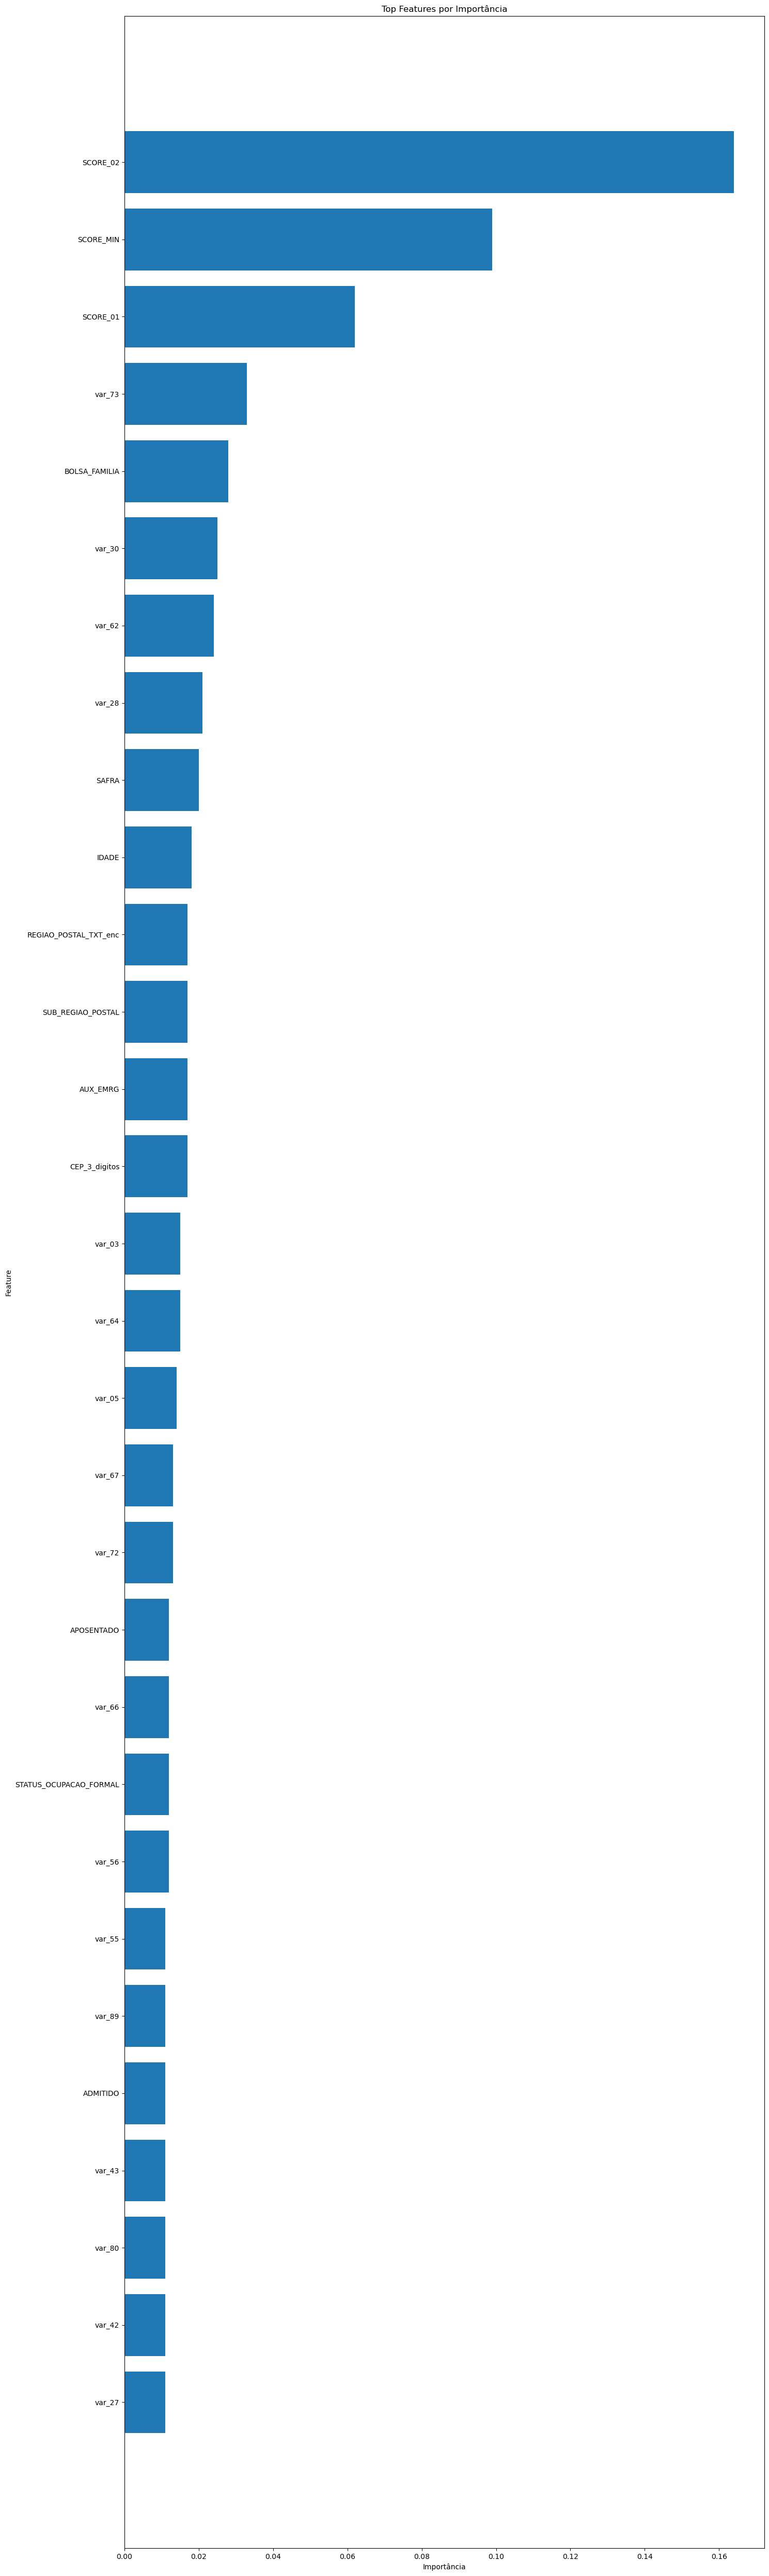

In [25]:
# Formata as importâncias com 3 casas decimais
feat_imp_table = feat_imp.sort_values(by="importance", ascending=False)
feat_imp_table["importance"] = feat_imp_table["importance"].round(3)

# Plotar importância das features (top N)
top_feats = feat_imp_table.head(TOP_N_FEATURES)

plt.figure(figsize=(15, 50))
plt.barh(top_feats['feature'], top_feats['importance'])
plt.gca().invert_yaxis()  # feature mais importante no topo
plt.title('Top Features por Importância')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [26]:
# Manter no X_train apenas as colunas selecionadas
X_train = X_train[selected_features_fs].copy()

### Correlação

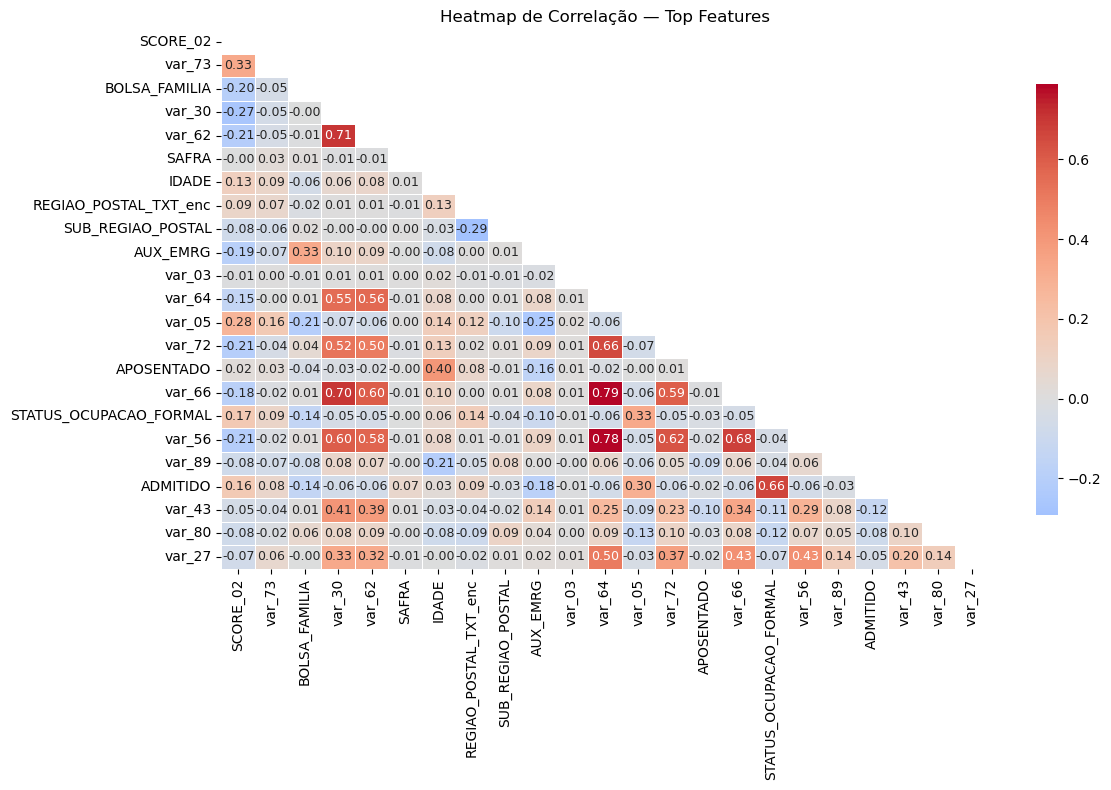

In [36]:
# calcula correlação apenas dessas features numéricas
corr = X_train.select_dtypes(include='number').corr()

# máscara para mostrar só metade da matriz
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8}
)

plt.title("Heatmap de Correlação — Top Features")
plt.tight_layout()
plt.show()


In [34]:
# Identificar pares de features com correlação absoluta acima do limiar

# calcula correlação apenas dessas features numéricas ignorando sinais
corr = X_train.select_dtypes(include='number').corr().abs()

# evita pares duplicados e remove a diagonal principal
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# percorre a matriz filtrada para encontrar pares altamente correlacionados
high_corr_pairs = [
    (row, col, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > 0.7
]

# lista final de pares com alta correlação
high_corr_pairs

[('var_30', 'var_62', 0.7057129402757985),
 ('var_30', 'var_66', 0.7003827757734489),
 ('var_64', 'var_66', 0.7883659450911858),
 ('var_64', 'var_56', 0.7812091772028879)]

In [37]:
# Remover a feature menos importante entre pares altamente correlacionados

# Conjunto para armazenar features marcadas para remoção (evita duplicidade)
to_drop = set()

# percorre cada par de features com alta correlação
for f1, f2, _ in high_corr_pairs:
    
    # recupera a importância da primeira feature
    imp_f1 = feat_imp_table.loc[
        feat_imp_table['feature'] == f1, 'importance'
    ].values[0]
    
    # recupera a importância da segunda feature
    imp_f2 = feat_imp_table.loc[
        feat_imp_table['feature'] == f2, 'importance'
    ].values[0]

    # compara importâncias e marca para remoção a menos relevante
    if imp_f1 < imp_f2:
        to_drop.add(f1)
    else:
        to_drop.add(f2)

# lista final de features sugeridas para remoção
list(to_drop)

['var_62', 'var_56', 'var_66']

In [38]:
# Drop de colunas redundantes ou sem importância para feature selection
cols_to_drop = to_drop
X_train = X_train.drop(columns=cols_to_drop)

In [39]:
X_train.shape

(831081, 20)

## Salvamento dos Dados Processados

In [40]:
# Salvar lista de features (excluindo a target) para referência futura
selected_features = [c for c in X_train.columns if c != TARGET]
with open(ARTIFACT_DIR / 'selected_features.pkl', 'wb') as f:
    pickle.dump(selected_features, f)

print(f'   ✓ Lista de features salva em: {ARTIFACT_DIR / "selected_features.pkl"}')
print(f'\n✅ Todos os dados processados foram salvos')


   ✓ Lista de features salva em: C:\pod\hackathon_pod_2025\ciencia\artifact\selected_features.pkl

✅ Todos os dados processados foram salvos
